In [ ]:
import json
import pandas as pd

with open("monster_india.json", "r", encoding="utf-8") as file:
    data = json.load(file)

df = pd.DataFrame(data)

print(df.shape)

(14146, 24)


In [ ]:
print(df.columns)

Index(['url', 'title', 'description', 'posted_at', 'crawled_at', '_id',
       'expires_at', 'job_type', 'company_name', 'qualifications',
       'responsibilities', 'industry', 'occupational_category', 'skills',
       'address_locality', 'address_region', 'address_country', 'postal_code',
       'street_address', 'salary', 'units', 'currency', 'experience',
       'months_of_experience'],
      dtype='object')


In [ ]:
print(df.head())

                                                 url  \
0  https://www.monsterindia.com/job/rm-retail-agr...   
1  https://www.monsterindia.com/job/software-engi...   
2  https://www.monsterindia.com/job/product-manag...   
3  https://www.monsterindia.com/job/location-sale...   
4  https://www.monsterindia.com/job/principal-sof...   

                                          title  \
0                                RM-Retail Agri   
1                          Software Engineer II   
2     Product Manager – Mortgage %26 Retail LAP   
3  Location Sales Manager-HOUSING FINANCE-Sales   
4                   Principal Software Engineer   

                                         description   posted_at  \
0  Job Description : A. Sourcing and Business Gen...  2021-07-27   
1  Position Type :  Full time   Type Of Hire :  E...  2021-07-23   
2  About Standard Chartered  We are a leading int...  2021-08-06   
3  Job Description : Job Role:   To lead a team o...  2021-05-26   
4  Product Overv

In [ ]:
print(df.isnull().sum())

url                      0
title                    0
description              0
posted_at                0
crawled_at               0
_id                      0
expires_at               0
job_type                 0
company_name             0
qualifications           0
responsibilities         0
industry                 0
occupational_category    0
skills                   0
address_locality         0
address_region           0
address_country          0
postal_code              0
street_address           0
salary                   0
units                    0
currency                 0
experience               0
months_of_experience     0
dtype: int64


In [ ]:
print("Duplicate jobs:", df["_id"].duplicated().sum())

Duplicate jobs: 0


In [ ]:
df["description"].fillna("").str.len().describe()

,description
count,14146.000000
mean,2323.254277
std,1796.091780
min,18.000000
25%,931.250000
50%,1985.500000
75%,3172.750000
max,19030.000000


In [ ]:
print(df.columns.tolist())

['url', 'title', 'description', 'posted_at', 'crawled_at', '_id', 'expires_at', 'job_type', 'company_name', 'qualifications', 'responsibilities', 'industry', 'occupational_category', 'skills', 'address_locality', 'address_region', 'address_country', 'postal_code', 'street_address', 'salary', 'units', 'currency', 'experience', 'months_of_experience']


In [ ]:
df.to_csv("raw_jobs.csv", index=False)

print("raw_jobs.csv created successfully")

raw_jobs.csv created successfully


In [ ]:
import pandas as pd

df = pd.read_csv("raw_jobs.csv")

print(df.shape)

(14146, 24)


In [ ]:
print("Number of jobs:", len(df))

Number of jobs: 14146


In [ ]:
print("Unique job titles:", df["title"].nunique())

Unique job titles: 10662


In [ ]:
print(df["title"].value_counts().head(10))

title
Software Engineer              76
Home Sales Officer 2           72
Home Sales Officer 1           71
Jio Point Assistant Manager    46
Jio Point Manager              45
RBB-Teller                     40
RBB-Personal Banker            38
RBB-Branch Mgr                 35
Senior Software Engineer       35
RM-Retail Agri                 33
Name: count, dtype: int64


In [ ]:
print(df["address_locality"].value_counts().head(10))

address_locality
Bengaluru / Bangalore       3990
India                       1595
Hyderabad / Secunderabad    1410
Pune                        1199
Mumbai                      1178
Chennai                     1127
Gurgaon / Gurugram           473
Noida                        390
Delhi                        251
Kolkata                      234
Name: count, dtype: int64


In [ ]:
print("Average description length:", df["description"].str.len().mean())

Average description length: 2323.2542768273715


In [ ]:
print("Minimum description length:", df["description"].str.len().min())

Minimum description length: 18


In [ ]:
print("Maximum description length:", df["description"].str.len().max())

Maximum description length: 19030


In [ ]:
print(df.isnull().sum())

url                          0
title                        0
description                  0
posted_at                    0
crawled_at                   0
_id                          0
expires_at                   7
job_type                     0
company_name                 7
qualifications           12872
responsibilities          1555
industry                   316
occupational_category       17
skills                    5073
address_locality             0
address_region               0
address_country              5
postal_code              14146
street_address           14146
salary                       7
units                        7
currency                     7
experience                   7
months_of_experience      4225
dtype: int64


In [ ]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 0


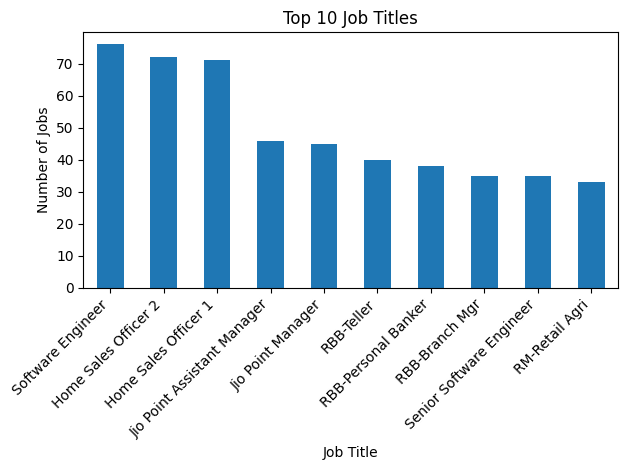

In [ ]:
import matplotlib.pyplot as plt

top_titles = df["title"].value_counts().head(10)

top_titles.plot(kind="bar")
plt.title("Top 10 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

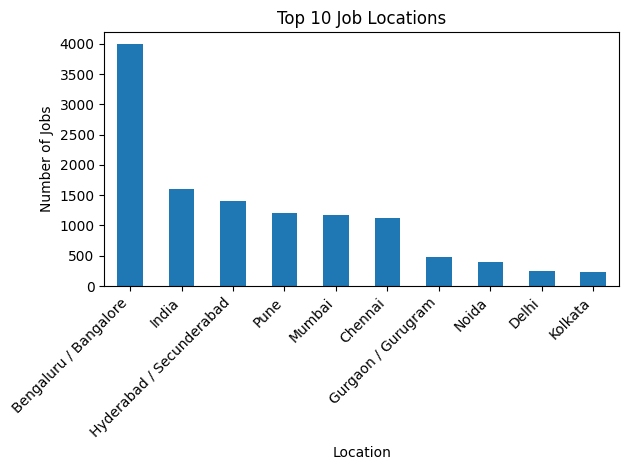

In [ ]:
location_counts = df["address_locality"].value_counts().head(10)

location_counts.plot(kind="bar")
plt.title("Top 10 Job Locations")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

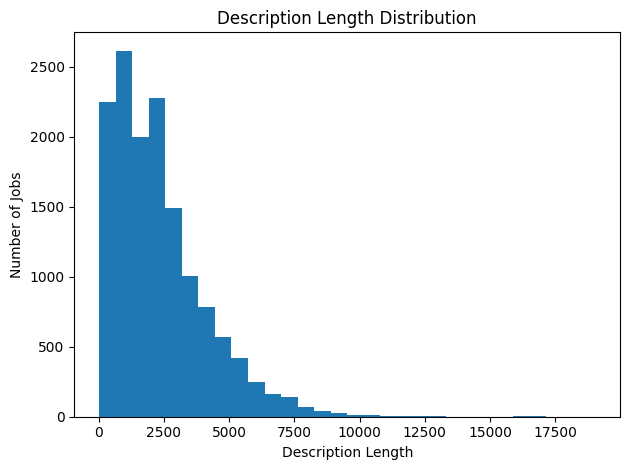

In [ ]:
description_length = df["description"].str.len()

description_length.plot(kind="hist", bins=30)
plt.title("Description Length Distribution")
plt.xlabel("Description Length")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

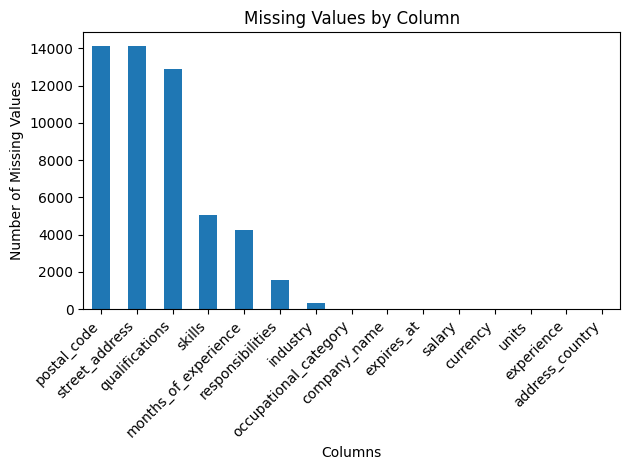

In [ ]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values.plot(kind="bar")
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

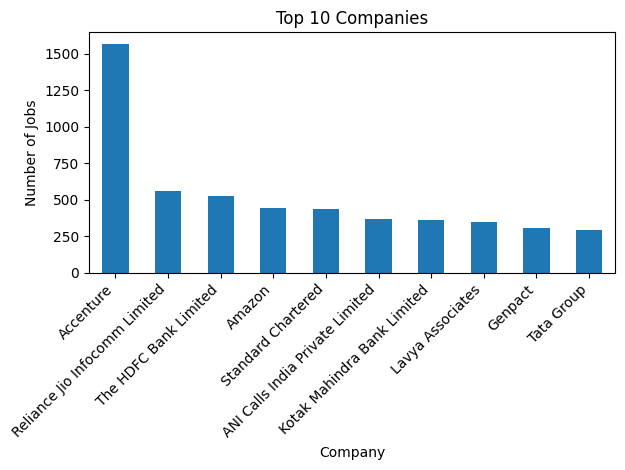

In [ ]:
company_counts = df["company_name"].value_counts().head(10)

company_counts.plot(kind="bar")
plt.title("Top 10 Companies")
plt.xlabel("Company")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()